In [ ]:
from db_manager import DatabaseManager


ModuleNotFoundError: No module named 'database'

In [ ]:
db_manager = DatabaseManager()

In [ ]:
db_manager.create_database('university')

(True, "Database 'university' created successfully")

In [ ]:
db_manager.list_databases()

['university']

In [ ]:
student_schema = {
    "student_id": int,
    "name": str,
    "Phone": str,
    "age": float,
    "Branch": str
}

In [ ]:
prof = {
    "prof_id": int,
    "name": str,
    "Phone": str,
    "age": float,
    "salary": int,
    "department": str
}

In [ ]:
db_manager.create_table('university', 'professor', prof, order=6, search_key= "prof_id")

(True, "Table 'professor' created successfully in database 'university'")

In [ ]:
db_manager.create_table('university', 'student', student_schema, order=6, search_key= "student_id")

(True, "Table 'student' created successfully in database 'university'")

In [ ]:
tables_name, _ = db_manager.list_tables('university')
tables_name

['professor', 'student']

In [ ]:
table_stu, _ = db_manager.get_table('university', 'student')
table_stu.get_all()

[]

In [ ]:
rec = {
    "student_id": 9,
    "name": "xyzf",
    "Phone": "846699",
    "age": 26.0,
    "Branch": "pech Eng1"
}

### INsertion

In [ ]:
table_stu.insert(rec)

(True, 9)

### Search

In [ ]:
table_stu.get(6)


(False, "Record with id '6' not found.")

### Update

In [ ]:
new_rec = {'student_id': 25,
 'name': 'xyzf',
 'Phone': '846',
 'age': 26.0,
 'Branch': 'pech Eng1'}

In [ ]:
table_stu.update('xyzf', new_rec)

(False, "Record with id 'xyzf' not found.")

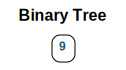

In [ ]:
from IPython.display import SVG, display

dot = table_stu.data.visualize_tree()
svg_data = dot.pipe(format='svg').decode('utf-8')
display(SVG(svg_data))

### Deletion

In [ ]:
table_stu.delete(6)

(False, "Record with id '6' not found.")

### Range Query

In [ ]:
import random
import string

def random_record_generator(schema, n):
    def random_value(data_type):
        if data_type == int:
            return random.randint(1, 100)
        elif data_type == float:
            return round(random.uniform(18.0, 60.0), 2)
        elif data_type == str:
            return ''.join(random.choices(string.ascii_letters, k=6))
        else:
            return None  # Unknown type

    records = []
    for _ in range(n):
        record = {}
        for field, field_type in schema.items():
            record[field] = random_value(field_type)
        records.append(record)
    return records

In [ ]:
import pandas as pd
records = random_record_generator(student_schema, 50)

for rec in records:
    table_stu.insert(rec)
 

In [ ]:
table_stu.range_query(63, 70)

[(63,
  {'student_id': 63,
   'name': 'HQJacl',
   'Phone': 'piaKKV',
   'age': 37.65,
   'Branch': 'SPmchF'}),
 (68,
  {'student_id': 68,
   'name': 'FsGZjq',
   'Phone': 'RVTXhw',
   'age': 54.88,
   'Branch': 'tjFyPM'}),
 (70,
  {'student_id': 70,
   'name': 'oKKJiW',
   'Phone': 'OOzUsO',
   'age': 50.33,
   'Branch': 'gByAnk'})]

## Performance testing